In [1]:
from format_conversions import ply_to_np
from visualize import visualize
from trainer import learn_pdf

import matplotlib.pyplot as plt
import numpy as np
import torch

from flow_models import KDE_Estimator, learn_1d_pdf, Lipschitz_Flow, RealNVP_Flow

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [ ]:
import torch

from utils import axis_angle_to_matrix, jitter, add_noise
from format_conversions import ply_to_np
import numpy as np
import copy
from trainer import DP_PCR

X = ply_to_np("datasets/bed_0516.ply") / 10 # shape (N, 3)
Y = copy.deepcopy(X)

Y = Y - Y.mean(axis=0) # shape (N, 3)
X = X - X.mean(axis=0)

rng = np.random.default_rng()
# get ground truth transformation
# GT_R1 = axis_angle_to_matrix([1, 0, 0], np.radians(rng.uniform(0, 25)))
# GT_R2 = axis_angle_to_matrix([0, 1, 0], np.radians(rng.uniform(0, 25)))
# GT_R3 = axis_angle_to_matrix([0, 0, 1], np.radians(rng.uniform(0, 25)))
# GT_S = np.array([rng.uniform(0.5, 0.7) if rng.random() < 0.5 else rng.uniform(1.3, 1.5)])
# GT_T = rng.uniform(0.5, 0.5, size=3)

# apply transformations to X
GT = np.eye(4)
# GT[:3, :3] = GT_R3 @ GT_R2 @ GT_R1
# GT[:3, 3] = GT_T
# X = GT_S * (GT[:3, :3] @ X.T).T + GT[:3, 3]

# X = add_noise(jitter(X))
print(GT)

# DP_PCR(X, Y, device='cuda:0')
device = 'cuda:0'
from trainer import learn_pdf
X = torch.from_numpy(X).to(dtype=torch.float32, device=device)
Y = torch.from_numpy(Y).to(dtype=torch.float32, device=device)

g1 = learn_pdf(Y[:, 0:1], model='KDE', device=device)
g2 = learn_pdf(Y[:, 1:2], model='KDE', device=device)
g3 = learn_pdf(Y[:, 2:3], model='KDE', device=device)
g4 = learn_pdf(torch.linalg.norm(Y-Y.mean(axis=0), axis=1, keepdim=True), model='KDE', device=device)
g5 = learn_pdf((Y-Y.mean(axis=0))[:, 0:2], model='KDE', device=device)
g6 = learn_pdf((Y-Y.mean(axis=0))[:, 1:3], model='KDE', device=device)
g7 = learn_pdf((Y-Y.mean(axis=0))[:, [0, 2]], model='KDE', device=device)

f1 = learn_pdf(X[:, 0:1], model='KDE', device=device)
f2 = learn_pdf(X[:, 1:2], model='KDE', device=device)
f3 = learn_pdf(X[:, 2:3], model='KDE', device=device)
f4 = learn_pdf(torch.linalg.norm(X-X.mean(axis=0), axis=1, keepdim=True), model='KDE', device=device)
f5 = learn_pdf((X-X.mean(axis=0))[:, 0:2], model='KDE', device=device)
f6 = learn_pdf((X-X.mean(axis=0))[:, 1:3], model='KDE', device=device)
f7 = learn_pdf((X-X.mean(axis=0))[:, [0, 2]], model='KDE', device=device)

for f, g in zip([f1, f2, f3, f4], [g1, g2, g3, g4]):
    _ = plt.hist(f.sample(20_000)[0].detach().cpu().numpy(), bins=100, alpha=0.5, label='f')
    _ = plt.hist(g.sample(20_000)[0].detach().cpu().numpy(), bins=100, alpha=0.5, label='g')
    plt.legend()
    plt.show()
for f, g in zip([f5, f6, f7], [g5, g6, g7]):
    f_samples = f.sample(20_000)[0].detach().cpu().numpy()
    g_samples = g.sample(20_000)[0].detach().cpu().numpy()
    _ = plt.hist2d(f_samples[:, 0], f_samples[:, 1], bins=100, label='f')
    plt.legend()
    plt.show()
    _ = plt.hist2d(g_samples[:, 0], g_samples[:, 1], bins=100, label='g')
    plt.legend()
    plt.show()

In [2]:
import torch
from trainer import learn_pdf
from format_conversions import ply_to_np
import numpy as np

X = ply_to_np("datasets/bed_0516.ply") / 10 # shape (N, 3)
X = X - X.mean(axis=0)

device = 'cuda:0'

X = torch.from_numpy(X).to(dtype=torch.float32, device=device)

f1 = learn_pdf(X[:, 0:1], model='KDE', device=device)
f2 = learn_pdf(X[:, 1:2], model='KDE', device=device)
f3 = learn_pdf(X[:, 2:3], model='KDE', device=device)
f4 = learn_pdf(torch.linalg.norm(X-X.mean(axis=0), axis=1, keepdim=True), model='KDE', device=device)
f5 = learn_pdf((X-X.mean(axis=0))[:, 0:2], model='KDE', device=device)
f6 = learn_pdf((X-X.mean(axis=0))[:, 1:3], model='KDE', device=device)
f7 = learn_pdf((X-X.mean(axis=0))[:, [0, 2]], model='KDE', device=device)

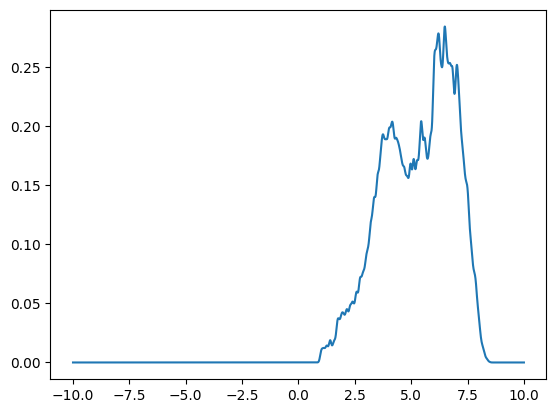

In [ ]:
xs = torch.linspace(-10, 10, 20_000).cuda()
ys = f5.log_prob(xs.reshape(-1, 1)).exp()
plt.plot(xs.cpu().numpy(), ys.cpu().numpy())

In [2]:
arr = ply_to_np('datasets/bed_0516.ply')
arr = (arr - arr.mean(axis=0)) / 10
arrt = torch.from_numpy(arr).float().cuda(0)

arr.shape, arr.max(axis=0), arr.min(axis=0)

((20000, 3),
 array([3.75458814, 6.98257011, 4.54015184]),
 array([-3.86046186, -5.96740989, -2.98484816]))

In [13]:
f = learn_pdf(arrt[:, [1, 2]], model='KDE')
loss = f.log_prob(arrt[:, [1, 2]][range(0, 20_000)]).mean()
loss2 = f.log_prob(arrt[:, [1, 2]]).mean()
loss3 = f.log_prob(arrt[:, [1, 2]]).mean()
loss4 = f.log_prob(arrt[:, [1, 2]]).mean()
loss5 = f.log_prob(arrt[:, [1, 2]]).mean()

In [ ]:
haha, haha_prob = learn_pdf(arrt[:, [1, 2]], model='KDE').sample(40_000)
_ = plt.hist2d(haha[:, 0].cpu().numpy(), haha[:, 1].cpu().numpy(), bins=100)

KDE_Estimator best_bw_factor: 0.010000
KDE_Estimator best_bw (absolute): 0.240877
scipy CV factor: 0.010000
relL2(KDE_Estimator, scipy same factor): 0.00000206
relL2(KDE_Estimator, scipy CV):          0.00000206


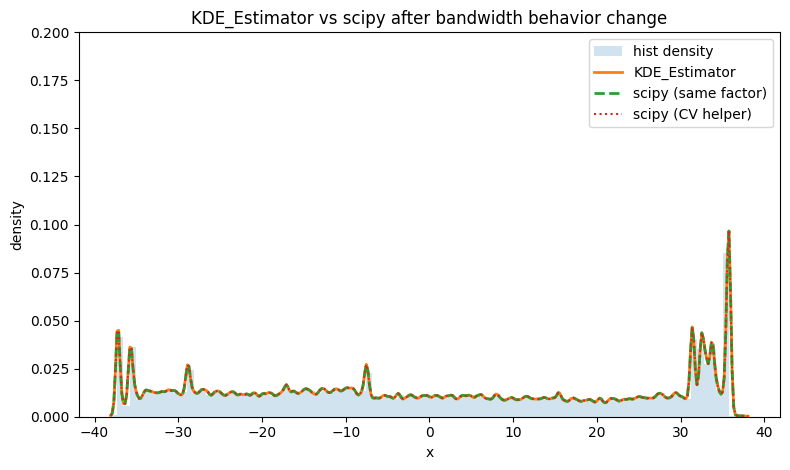

In [ ]:
# New check: KDE_Estimator now uses scipy-like bandwidth factors internally.
import flow_models

KDE_Estimator = flow_models.KDE_Estimator
learn_1d_pdf = flow_models.learn_1d_pdf

y = arr[:, 0:1]
y_flat = y[:, 0]

x_grid = np.linspace(y_flat.min(), y_flat.max(), 400)
x_grid_t = torch.from_numpy(x_grid).to(dtype=torch.float32, device='cuda:0').unsqueeze(1)

kde_est = KDE_Estimator(latent_size=1, device='cuda:0').fit(
    torch.from_numpy(y).to(dtype=torch.float32, device='cuda:0')
)
dens_est = np.exp(kde_est.log_prob(x_grid_t).detach().cpu().numpy())

# scipy density using the exact factor selected by KDE_Estimator
kde_scipy_same_factor = flow_models.gaussian_kde(y_flat, bw_method=kde_est.best_bw_factor)
dens_scipy_same_factor = kde_scipy_same_factor.evaluate(x_grid)

# scipy density from independent CV helper (should pick the same/near factor)
kde_scipy_cv = learn_1d_pdf(y_flat, cv_folds=20, bw_values=np.logspace(-2, 1, 20).tolist())
dens_scipy_cv = kde_scipy_cv.evaluate(x_grid)

rel_same = rel_l2(dens_est, dens_scipy_same_factor)
rel_cv = rel_l2(dens_est, dens_scipy_cv)

print(f"KDE_Estimator best_bw_factor: {kde_est.best_bw_factor:.6f}")
print(f"KDE_Estimator best_bw (absolute): {kde_est.best_bw:.6f}")
print(f"scipy CV factor: {kde_scipy_cv.factor:.6f}")
print(f"relL2(KDE_Estimator, scipy same factor): {rel_same:.8f}")
print(f"relL2(KDE_Estimator, scipy CV):          {rel_cv:.8f}")

plt.figure(figsize=(8, 4.8))
_ = plt.hist(y_flat, bins=100, density=True, alpha=0.2, label='hist density')
plt.plot(x_grid, dens_est, lw=2, label='KDE_Estimator')
plt.plot(x_grid, dens_scipy_same_factor, lw=2, ls='--', label='scipy (same factor)')
plt.plot(x_grid, dens_scipy_cv, lw=1.5, ls=':', label='scipy (CV helper)')
plt.title('KDE_Estimator vs scipy after bandwidth behavior change')
plt.xlabel('x')
plt.ylabel('density')
plt.ylim(0, 0.2)
plt.legend()
plt.tight_layout()
plt.show()